# 07 — Person-Days Diagnostic: why rankings reflect population, not heat exposure

Person-days (heat-day count × population) should rank neighbourhoods by *combined*
exposure burden — both how often they are hot *and* how many people are affected.
This notebook investigates why, in practice, person-day rankings are nearly identical
to pure population rankings across all three cities and both threshold definitions.

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`.

## Setup

In [7]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city, load_tx90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

DATA_DIR      = 'data'
DIAG_YEAR     = 2020
ABS_THRESHOLD = 30.0
PERCENTILE    = 90
CITY_KEYS     = ['salvador', 'teresina', 'caceres']

cities     = {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities[c] = da

thresholds = {c: load_tx90p_threshold(c, DATA_DIR) for c in CITY_KEYS}
gdfs       = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

# Pre-compute TX90p annual heat-day counts
tx_annual = {c: {} for c in CITY_KEYS}
for c in CITY_KEYS:
    tx_annual[c][PERCENTILE] = count_doy_exceedances(
        cities[c], thresholds[c].sel(percentile=PERCENTILE)
    )

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 3, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 26.0–88.4 °C
teresina TX90p threshold: shape {'percentile': 3, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 32.7–65.9 °C
caceres TX90p threshold: shape {'percentile': 3, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 30.9–52.7 °C
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


In [8]:
def build_nbhd_table(city_key, year):
    """Per-neighbourhood dataframe: population, heat days, person-days, ranks."""
    da       = cities[city_key]
    gdf      = gdfs[city_key]
    pop_grid = load_pop_grid(city_key, year)

    abs_hd = compute_absolute_heat_days(da, year, ABS_THRESHOLD)
    tx_hd  = (
        tx_annual[city_key][PERCENTILE]
        .isel(time=(tx_annual[city_key][PERCENTILE].time.dt.year == year))
        .squeeze('time')
    )

    pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop_grid, gdf, col='population')
    abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, gdf, col='abs_hd')
    tx_hd_nbhd  = aggregate_to_neighbourhoods(tx_hd,  gdf, col='tx90p_hd')
    abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(abs_hd, pop_grid), gdf, col='abs_pd')
    tx_pd_nbhd  = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(tx_hd,  pop_grid), gdf, col='tx90p_pd')

    df = gdf[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['abs_hd']     = abs_hd_nbhd['abs_hd'].values
    df['tx90p_hd']   = tx_hd_nbhd['tx90p_hd'].values
    df['abs_pd']     = abs_pd_nbhd['abs_pd'].values
    df['tx90p_pd']   = tx_pd_nbhd['tx90p_pd'].values
    for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)
    return df.dropna().reset_index(drop=True)

tables = {c: build_nbhd_table(c, DIAG_YEAR) for c in CITY_KEYS}

## Threshold choice: absolute vs TX90p

A fixed 30 °C threshold applied to all cities ignores local climate baseline.  In Teresina — where daily maximum temperatures routinely exceed 35 °C — virtually every day of the year crosses the 30 °C line.  The threshold carries no spatial information: every neighbourhood registers ~340 heat days and the map is uniform.

TX90p adapts to local conditions.  A day is a heat day only when temperature exceeds the local 90th percentile for that calendar day, computed from the baseline period.  This produces a climatologically meaningful definition that is comparable across cities.

The table below shows what temperatures the TX90p threshold corresponds to in each city, and what heat-day ranges result from each approach.  The maps show how the two approaches distribute heat days across neighbourhoods.

**Choice for IBM deliverable:** TX90p.  The absolute threshold saturates in hot cities and should not be used for intra-city neighbourhood comparisons.  The key limitation of TX90p is that it is a *relative* threshold — by construction ~10 % of all days are heat days in every city — so it cannot be used to compare absolute heat burden between cities.

,Absolute threshold (°C),TX90p mean (°C),TX90p min (°C),TX90p max (°C),Abs hd range (days),Abs hd CV,TX90p hd range (days),TX90p hd CV
City,,,,,,,,
"Salvador, Brazil",30,34.7,26.0,53.3,0–244,0.44,0–12,0.64
"Teresina, Brazil",30,35.9,32.7,52.4,320–356,0.01,4–10,0.19
"Cáceres, Brazil",30,35.4,30.9,39.7,327–335,0.01,122–134,0.02


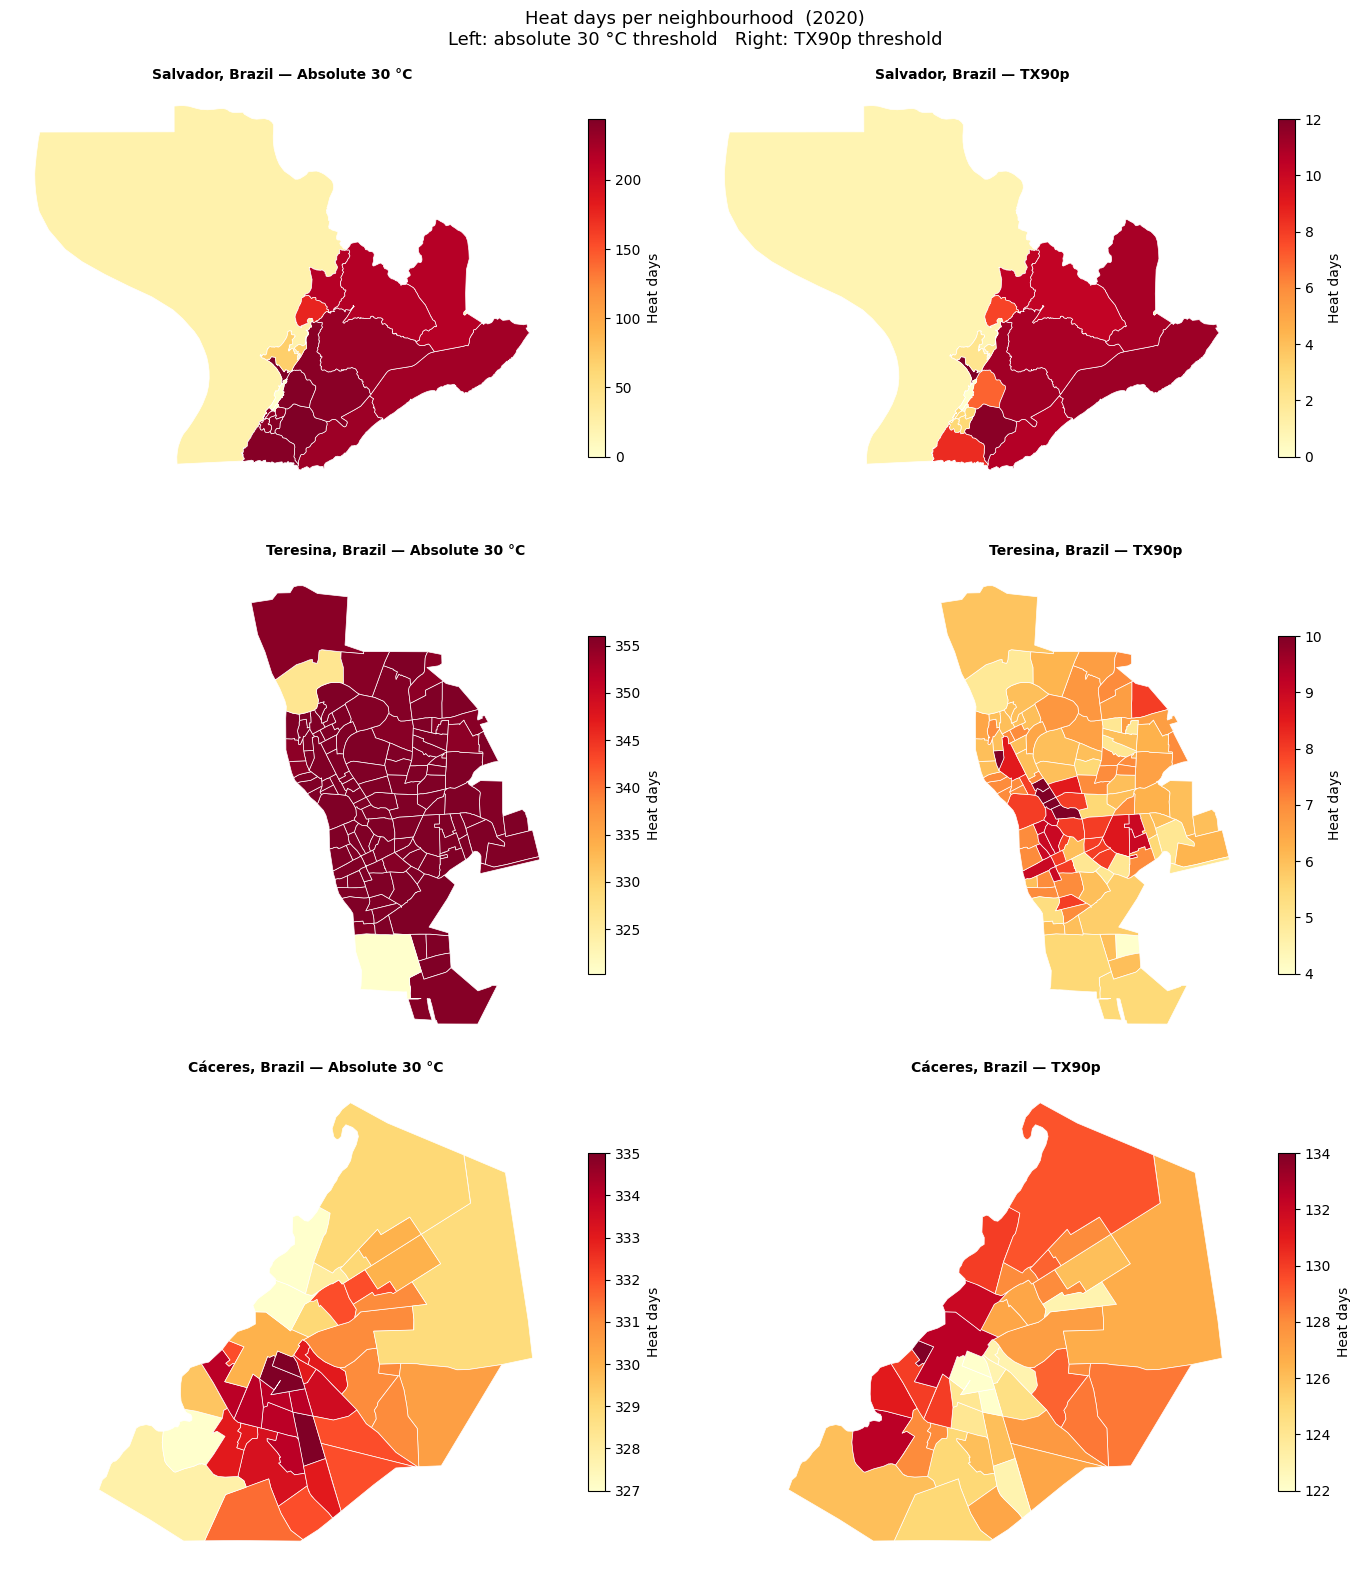

In [9]:
import matplotlib.colors as mcolors

# ---- Table: threshold temperatures and heat-day ranges -----------------------
thresh_rows = []
for c in CITY_KEYS:
    t90 = thresholds[c].sel(percentile=90)
    df  = tables[c]
    thresh_rows.append({
        'City':                    CITIES[c]['label'],
        'Absolute threshold (°C)': ABS_THRESHOLD,
        'TX90p mean (°C)':         float(t90.mean()),
        'TX90p min (°C)':          float(t90.min()),
        'TX90p max (°C)':          float(t90.max()),
        'Abs hd range (days)':     f"{df['abs_hd'].min():.0f}–{df['abs_hd'].max():.0f}",
        'Abs hd CV':               df['abs_hd'].std() / df['abs_hd'].mean() if df['abs_hd'].mean() > 0 else 0,
        'TX90p hd range (days)':   f"{df['tx90p_hd'].min():.0f}–{df['tx90p_hd'].max():.0f}",
        'TX90p hd CV':             df['tx90p_hd'].std() / df['tx90p_hd'].mean() if df['tx90p_hd'].mean() > 0 else 0,
    })

thresh_df = pd.DataFrame(thresh_rows).set_index('City')
fmt = {
    'Absolute threshold (°C)': '{:.0f}',
    'TX90p mean (°C)': '{:.1f}', 'TX90p min (°C)': '{:.1f}', 'TX90p max (°C)': '{:.1f}',
    'Abs hd CV': '{:.2f}', 'TX90p hd CV': '{:.2f}',
    'Abs hd range (days)': '{}', 'TX90p hd range (days)': '{}',
}
display(
    thresh_df.style.format(fmt)
    .background_gradient(subset=['Abs hd CV', 'TX90p hd CV'], cmap='RdYlGn', axis=None)
    .set_caption(
        f'Threshold comparison ({DIAG_YEAR})  |  '
        'CV near 0 = no spatial variation = threshold is not useful for neighbourhood ranking'
    )
    .set_table_styles(table_styles)
)

# ---- Maps: heat days by neighbourhood, both thresholds ----------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(
    f'Heat days per neighbourhood  ({DIAG_YEAR})\n'
    'Left: absolute 30 °C threshold   Right: TX90p threshold',
    fontsize=13,
)

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']

    # Merge table values onto the GeoDataFrame for plotting
    plot_gdf = gdfs[c].merge(
        df[['name', 'abs_hd', 'tx90p_hd', 'population']],
        on='name', how='left',
    )

    for col, (col_name, title_suffix, cmap) in enumerate([
        ('abs_hd',   'Absolute 30 °C',  'YlOrRd'),
        ('tx90p_hd', 'TX90p',           'YlOrRd'),
    ]):
        ax = axes[row][col]
        plot_gdf.plot(
            column=col_name, ax=ax, cmap=cmap,
            legend=True,
            legend_kwds={'label': 'Heat days', 'shrink': 0.7},
            edgecolor='white', linewidth=0.5, missing_kwds={'color': 'lightgrey'},
        )
        ax.set_title(f'{label} — {title_suffix}', fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Finding 1 — Person-day rankings are driven by population, not heat days

**What this test shows:** if person-days captured both heat *and* population variation
equally, neighbourhood ranks would sit somewhere between a pure population ranking and
a pure heat-day ranking.  Instead, across all three cities and both threshold
definitions, person-day rank is almost perfectly explained by population rank alone.

The figure below plots population rank against person-day rank for each city.
A perfect diagonal means person-days = population × constant — the heat-day
dimension is adding nothing.

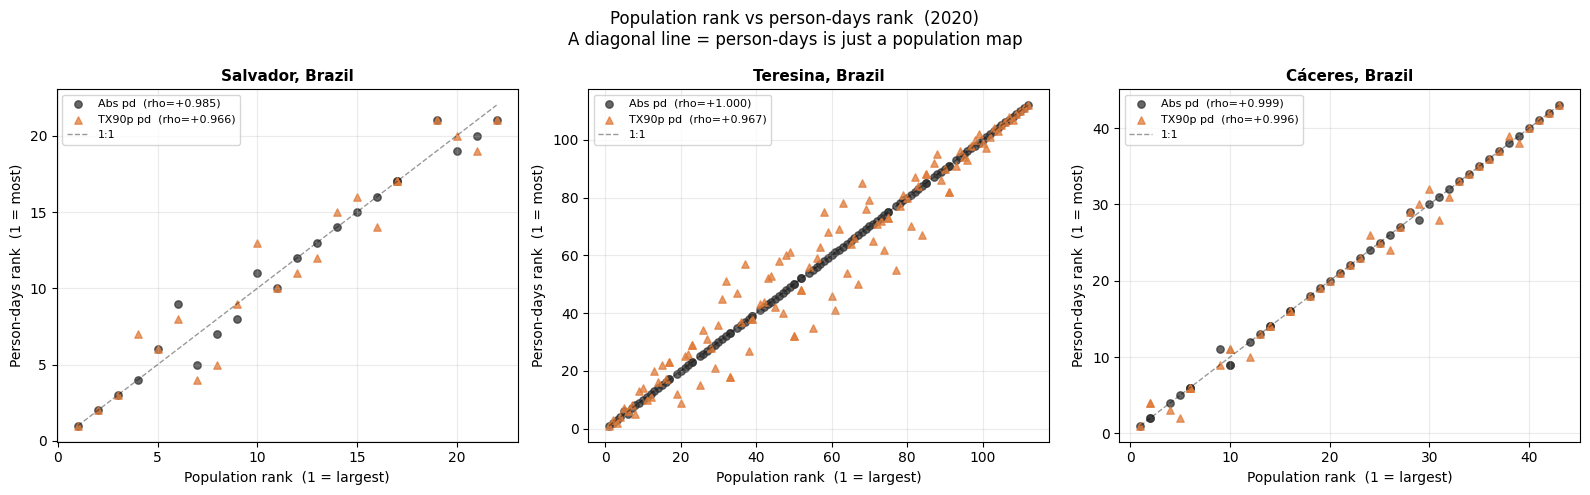

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Population rank vs person-days rank  ({DIAG_YEAR})\n'
    'A diagonal line = person-days is just a population map',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']

    rho_abs, _ = spearmanr(df['rank_population'], df['rank_abs_pd'])
    rho_tx,  _ = spearmanr(df['rank_population'], df['rank_tx90p_pd'])

    ax.scatter(df['rank_population'], df['rank_abs_pd'],
               s=28, alpha=0.75, color='#333333', label=f'Abs pd  (rho={rho_abs:+.3f})')
    ax.scatter(df['rank_population'], df['rank_tx90p_pd'],
               s=28, alpha=0.75, color='#e07b39', marker='^',
               label=f'TX90p pd  (rho={rho_tx:+.3f})')
    ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4, label='1:1')

    ax.set_xlabel('Population rank  (1 = largest)', fontsize=10)
    ax.set_ylabel('Person-days rank  (1 = most)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Summary statistics — all three cities

The table below captures the key numbers behind the finding.  The **CV columns**
compare how much each variable varies across neighbourhoods relative to its mean —
a higher CV means that variable has more influence on neighbourhood-level differences.
The **Spearman ρ columns** measure how strongly two rankings agree (1 = identical,
0 = unrelated).

Read across a row: if population CV >> heat-day CV, population dominates the product.
If ρ(pop, person-days) ≈ 1, the person-day map is a population map.

In [11]:
rows = []
for c in CITY_KEYS:
    df = tables[c]
    rho_pop_abs_pd,  _ = spearmanr(df['population'], df['abs_pd'])
    rho_pop_tx_pd,   _ = spearmanr(df['population'], df['tx90p_pd'])
    rho_abshd_abspd, _ = spearmanr(df['abs_hd'],     df['abs_pd'])
    rho_txhd_txpd,   _ = spearmanr(df['tx90p_hd'],   df['tx90p_pd'])
    rho_abspd_txpd,  _ = spearmanr(df['abs_pd'],      df['tx90p_pd'])
    rho_abshd_txhd,  _ = spearmanr(df['abs_hd'],      df['tx90p_hd'])

    rows.append({
        'City':             CITIES[c]['label'],
        'CV: population':   df['population'].std() / df['population'].mean(),
        'CV: abs hd':       df['abs_hd'].std()     / df['abs_hd'].mean() if df['abs_hd'].mean() > 0 else np.nan,
        'CV: TX90p hd':     df['tx90p_hd'].std()   / df['tx90p_hd'].mean() if df['tx90p_hd'].mean() > 0 else np.nan,
        'Abs hd range':     f"{df['abs_hd'].min():.0f}–{df['abs_hd'].max():.0f} days",
        'TX90p hd range':   f"{df['tx90p_hd'].min():.0f}–{df['tx90p_hd'].max():.0f} days",
        '\u03c1 pop vs abs pd':       rho_pop_abs_pd,
        '\u03c1 pop vs TX90p pd':     rho_pop_tx_pd,
        '\u03c1 abs hd vs abs pd':    rho_abshd_abspd,
        '\u03c1 TX90p hd vs TX90p pd': rho_txhd_txpd,
        '\u03c1 abs pd vs TX90p pd':  rho_abspd_txpd,
        '\u03c1 abs hd vs TX90p hd':  rho_abshd_txhd,
    })

summary = pd.DataFrame(rows).set_index('City')

cv_cols  = ['CV: population', 'CV: abs hd', 'CV: TX90p hd']
rho_cols = [
    '\u03c1 pop vs abs pd', '\u03c1 pop vs TX90p pd',
    '\u03c1 abs hd vs abs pd', '\u03c1 TX90p hd vs TX90p pd',
    '\u03c1 abs pd vs TX90p pd', '\u03c1 abs hd vs TX90p hd',
]

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

fmt = {c: '{:.3f}' for c in cv_cols + rho_cols}
fmt['Abs hd range']   = '{}'
fmt['TX90p hd range'] = '{}'

display(
    summary.style
    .format(fmt)
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .background_gradient(subset=rho_cols, cmap='RdYlGn', axis=None, vmin=-1, vmax=1)
    .set_caption(
        f'Neighbourhood-level summary  ({DIAG_YEAR})  |  '
        'CV = coefficient of variation  |  \u03c1 = Spearman rank correlation'
    )
    .set_table_styles(table_styles)
)

,CV: population,CV: abs hd,CV: TX90p hd,Abs hd range,TX90p hd range,ρ pop vs abs pd,ρ pop vs TX90p pd,ρ abs hd vs abs pd,ρ TX90p hd vs TX90p pd,ρ abs pd vs TX90p pd,ρ abs hd vs TX90p hd
City,,,,,,,,,,,
"Salvador, Brazil",1.041,0.441,0.642,0–244 days,0–12 days,0.985,0.966,0.331,0.701,0.983,0.498
"Teresina, Brazil",0.878,0.012,0.190,320–356 days,4–10 days,1.000,0.967,-0.014,0.072,0.967,0.309
"Cáceres, Brazil",0.506,0.007,0.024,327–335 days,122–134 days,0.999,0.996,0.510,-0.309,0.995,-0.556


## Finding 2 — Three distinct mechanisms, one shared result

The population-dominance pattern arises for different reasons in each city.
The figure below makes each mechanism visible.

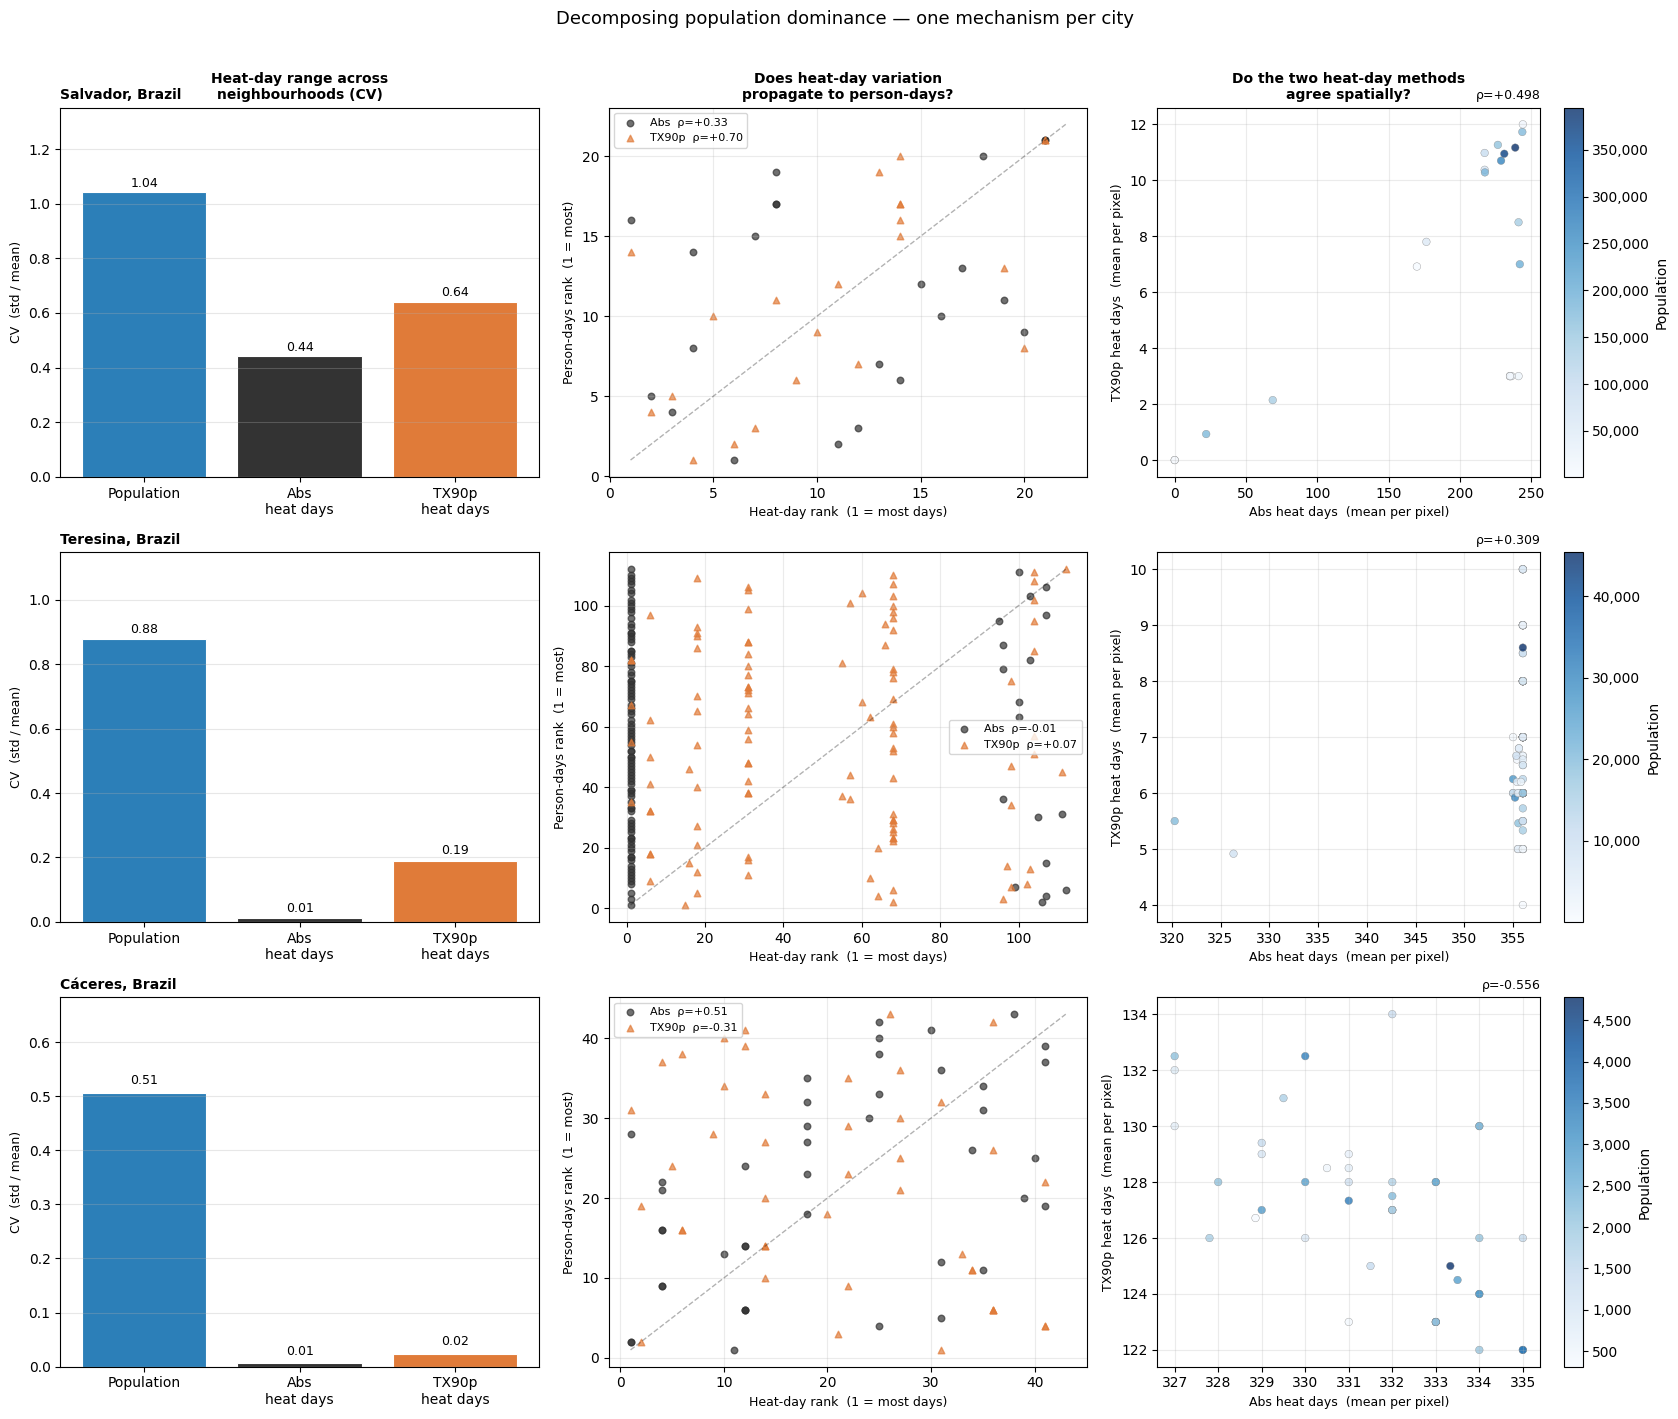

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle(
    'Decomposing population dominance — one mechanism per city',
    fontsize=13, y=1.01,
)

panel_titles = [
    'Heat-day range across\nneighbourhoods (CV)',
    'Does heat-day variation\npropagate to person-days?',
    'Do the two heat-day methods\nagree spatially?',
]
for ax, t in zip(axes[0], panel_titles):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']

    # ---- Panel 1: CV bar chart ------------------------------------------------
    ax = axes[row][0]
    cv_vals = [
        df['population'].std() / df['population'].mean(),
        df['abs_hd'].std()     / df['abs_hd'].mean()     if df['abs_hd'].mean()   > 0 else 0,
        df['tx90p_hd'].std()   / df['tx90p_hd'].mean()   if df['tx90p_hd'].mean() > 0 else 0,
    ]
    bars = ax.bar(['Population', 'Abs\nheat days', 'TX90p\nheat days'],
                  cv_vals,
                  color=['#2c7fb8', '#333333', '#e07b39'],
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cv_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('CV  (std / mean)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0, max(cv_vals) * 1.25 + 0.05)

    # ---- Panel 2: heat-day rank vs person-day rank (does hd variation propagate?) --
    ax = axes[row][1]
    n  = len(df)
    rho_abs, _ = spearmanr(df['rank_abs_hd'],   df['rank_abs_pd'])
    rho_tx,  _ = spearmanr(df['rank_tx90p_hd'], df['rank_tx90p_pd'])
    ax.scatter(df['rank_abs_hd'],   df['rank_abs_pd'],
               s=22, alpha=0.7, color='#333333',
               label=f'Abs  \u03c1={rho_abs:+.2f}')
    ax.scatter(df['rank_tx90p_hd'], df['rank_tx90p_pd'],
               s=22, alpha=0.7, color='#e07b39', marker='^',
               label=f'TX90p  \u03c1={rho_tx:+.2f}')
    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('Heat-day rank  (1 = most days)', fontsize=9)
    ax.set_ylabel('Person-days rank  (1 = most)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    # ---- Panel 3: abs hd vs tx90p hd (do the two methods see the same space?) ----
    ax = axes[row][2]
    rho_hd, _ = spearmanr(df['abs_hd'], df['tx90p_hd'])
    sc = ax.scatter(df['abs_hd'], df['tx90p_hd'],
                    c=df['population'], cmap='Blues',
                    s=30, alpha=0.8, edgecolors='grey', linewidth=0.3)
    plt.colorbar(sc, ax=ax, label='Population', format=mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}'))
    ax.set_xlabel('Abs heat days  (mean per pixel)', fontsize=9)
    ax.set_ylabel('TX90p heat days  (mean per pixel)', fontsize=9)
    ax.set_title(f'\u03c1={rho_hd:+.3f}', fontsize=9, loc='right')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Interpretation

### What the panels show

**Column 1 — CV comparison.**  The bar height tells you how much each variable
varies *across neighbourhoods* relative to its mean.  Where population CV is much
taller than heat-day CV, population is the only driver of neighbourhood differences
in the person-days product.

**Column 2 — Does heat-day variation propagate to person-days?**  If heat days
controlled person-day rankings, the scatter would lie on the diagonal (rank-for-rank
agreement).  A flat cloud or negative slope means heat-day differences between
neighbourhoods have been erased by population.

**Column 3 — Do the two heat-day methods agree spatially?**  Points coloured by
population.  A tight positive slope means both methods flag the same neighbourhoods.
A flat or negative slope means the choice of threshold definition changes *which*
neighbourhoods look hot — yet even this spatial disagreement is invisible in the
person-days product because population dominates regardless.

---

### Three mechanisms

**Teresina — absolute threshold saturation.**  The 30 °C absolute threshold is so
low for Teresina that virtually every pixel exceeds it on nearly every day of the year
(range 320–356 days, CV = 0.01).  There is no spatial signal: heat days are a
near-constant, so person-days ≈ population × constant and ρ(pop, abs_pd) = +1.000.

**Salvador — population variance dominance.**  Absolute heat days vary meaningfully
across neighbourhoods (range 0–244 days, CV = 0.44), but population CV = 1.04 is
more than twice as large.  When you multiply two variables together, the one with
greater relative spread dominates the product.  Heat-day differences exist, but
population differences are large enough to swamp them.

**Cáceres — both thresholds saturated, and spatially anti-correlated.**  Both
absolute (CV = 0.01) and TX90p (CV = 0.02) heat days have near-zero spatial
variation, so person-days ≈ population in both cases (ρ ≈ +0.998).  The additional
wrinkle is that the two methods are *negatively* correlated spatially (ρ = −0.56):
the neighbourhoods flagged most often by the absolute threshold are flagged *least*
often by TX90p, and vice versa.  This is consistent with persistently hot areas having
a correspondingly high seasonal baseline — they rarely exceed their own 90th percentile
even though they exceed the fixed 30 °C threshold on almost every day.  Despite this
spatial flip between methods, person-day rankings agree almost perfectly (ρ = +0.995)
because both are resolved almost entirely by population.

---

### What this means for the analysis

Person-days as computed here answers the question *"where is aggregate heat burden
largest?"* — and the answer is always *"the most densely populated neighbourhoods"*.
At 1 km resolution within a single city, temperature does not vary enough between
neighbourhoods for the heat-day dimension to shift rankings meaningfully.

The spatial heat-day contrasts that notebooks 03 and 05 identify — genuine differences
in how often neighbourhoods exceed a threshold — are real, but they are lost when
multiplied by population because population spread is larger.

**Consequence for notebooks 04 and 06:** the quadrant plots showing near-perfect
linear alignment between absolute and TX90p person-day rankings are not a bug;
they reflect the fact that both methods produce near-identical population maps.

**If the goal is to rank neighbourhoods by heat exposure intensity** (independent of
size), use mean heat days per pixel — the output of notebooks 03 and 05.  
**If the goal is total burden** (how many person-days of exposure does a city
accumulate, aggregated to a higher level such as the whole city or district), person-days
remain the right metric — but comparisons across *neighbourhoods* within a city will
largely reflect population distribution.

## Recommended visualisation approach

**In the tool:** colour neighbourhoods by person-days (total heat burden).  This correctly answers "where does aggregate exposure accumulate?" and is the right metric for prioritising intervention by impact — more people benefitting from a cooling intervention always counts for more.

**Alongside the tool:** a quadrant plot separates the two dimensions so that neighbourhoods which are hot but small (high heat days, low population) are still visible and actionable — they may be lower-impact but higher-urgency for heat health response.

Quadrant boundaries are set at the **city median** for each dimension.  This is a relative classification within each city, consistent with the TX90p logic of relative rather than absolute thresholds.

| Quadrant | Interpretation | Suggested action |
|---|---|---|
| **Hot + Dense** | Highest aggregate burden; greatest intervention impact | Priority for cooling infrastructure |
| **Hot + Sparse** | Elevated heat risk per person; fewer beneficiaries | Heat health surveillance, early warning |
| **Cool + Dense** | Large population, lower heat exposure | Monitor; lower immediate heat priority |
| **Cool + Sparse** | Low burden, low population | Baseline |

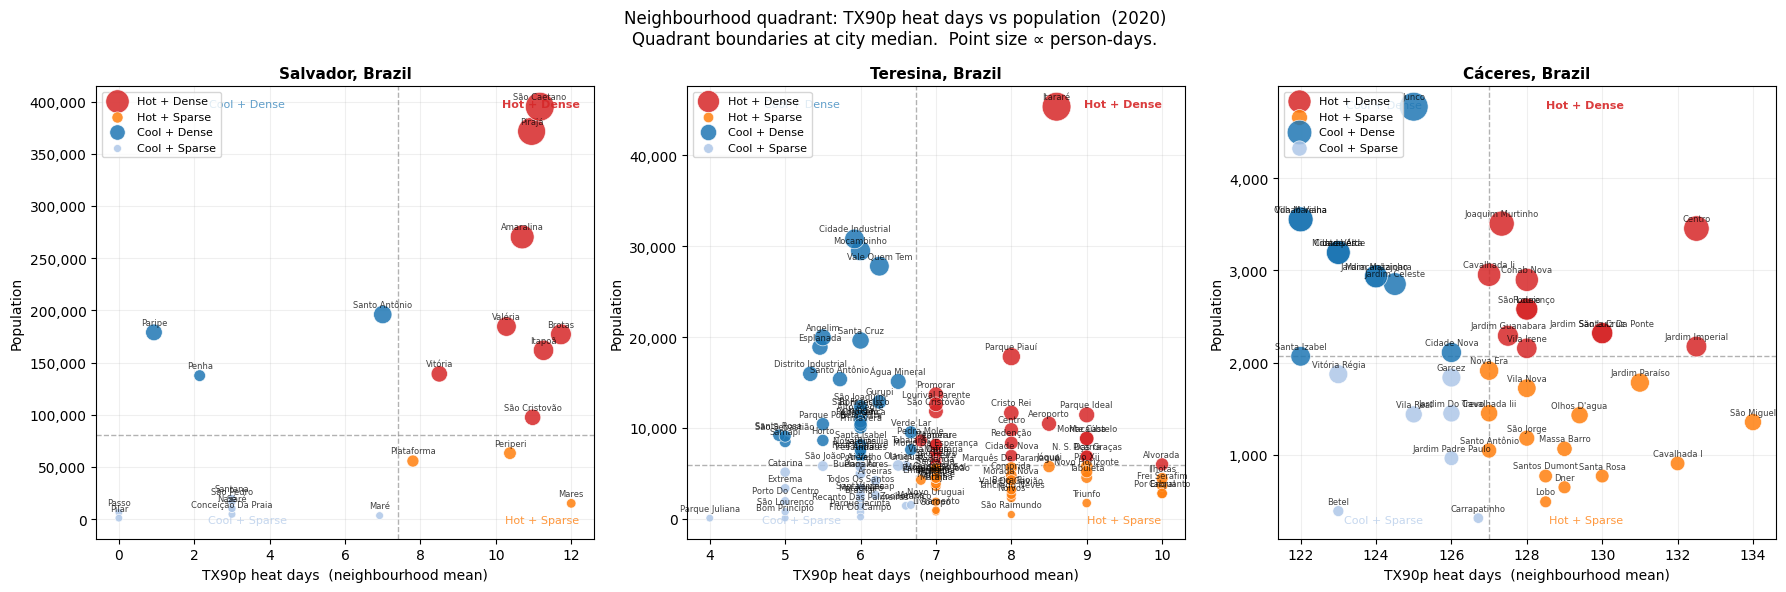


Neighbourhoods per quadrant  (2020, TX90p)

--- Salvador, Brazil ---


,N neighbourhoods,Total population,Mean heat days,Total person-days
quadrant,,,,
Hot + Dense,8,"1,796,761",10.7,"19,359,510"
Hot + Sparse,3,"133,954",10.1,"1,230,499"
Cool + Dense,3,"512,319",3.4,"3,234,739"
Cool + Sparse,8,"71,794",2.7,"197,859"


--- Teresina, Brazil ---


,N neighbourhoods,Total population,Mean heat days,Total person-days
quadrant,,,,
Hot + Dense,24,"254,610",7.9,"2,029,519"
Hot + Sparse,32,"118,996",7.9,"940,300"
Cool + Dense,32,"412,342",5.9,"2,452,051"
Cool + Sparse,24,"72,067",5.8,"417,898"


--- Cáceres, Brazil ---


,N neighbourhoods,Total population,Mean heat days,Total person-days
quadrant,,,,
Hot + Dense,11,"29,233",129.0,"3,763,546"
Hot + Sparse,14,"16,526",129.2,"2,132,160"
Cool + Dense,11,"34,365",123.5,"4,239,501"
Cool + Sparse,7,"8,264",125.1,"1,032,330"


In [13]:
QUADRANT_COLORS = {
    'Hot + Dense':   '#d62728',
    'Hot + Sparse':  '#ff7f0e',
    'Cool + Dense':  '#1f77b4',
    'Cool + Sparse': '#aec7e8',
}

def assign_quadrant(hd, pop, hd_med, pop_med):
    hot  = hd  >= hd_med
    dense = pop >= pop_med
    if hot and dense:   return 'Hot + Dense'
    if hot:             return 'Hot + Sparse'
    if dense:           return 'Cool + Dense'
    return 'Cool + Sparse'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Neighbourhood quadrant: TX90p heat days vs population  ({DIAG_YEAR})\n'
    'Quadrant boundaries at city median.  Point size ∝ person-days.',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df     = tables[c].copy()
    label  = CITIES[c]['label']
    hd_med  = df['tx90p_hd'].median()
    pop_med = df['population'].median()

    df['quadrant'] = df.apply(
        lambda r: assign_quadrant(r['tx90p_hd'], r['population'], hd_med, pop_med), axis=1
    )

    # Size proportional to person-days (normalised within city)
    pd_norm = (df['tx90p_pd'] / df['tx90p_pd'].max()) * 400 + 30

    for q, color in QUADRANT_COLORS.items():
        mask = df['quadrant'] == q
        ax.scatter(
            df.loc[mask, 'tx90p_hd'],
            df.loc[mask, 'population'],
            s=pd_norm[mask], color=color, alpha=0.85,
            edgecolors='white', linewidth=0.5, label=q, zorder=3,
        )

    # Label every neighbourhood
    for _, row in df.iterrows():
        ax.annotate(
            row['name'], (row['tx90p_hd'], row['population']),
            fontsize=6, alpha=0.75, ha='center', va='bottom',
            xytext=(0, 4), textcoords='offset points',
        )

    # Quadrant dividers
    ax.axvline(hd_med,  color='grey', linewidth=1, linestyle='--', alpha=0.6)
    ax.axhline(pop_med, color='grey', linewidth=1, linestyle='--', alpha=0.6)

    # Quadrant labels (background boxes)
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.text(hd_med * 0.5 + xlim[0] * 0.5, ylim[1] * 0.97, 'Cool + Dense',
            ha='center', va='top', fontsize=8, color='#1f77b4', alpha=0.7)
    ax.text(xlim[1] * 0.97, ylim[1] * 0.97, 'Hot + Dense',
            ha='right', va='top', fontsize=8, color='#d62728', fontweight='bold', alpha=0.9)
    ax.text(xlim[1] * 0.97, ylim[0] + (ylim[1] - ylim[0]) * 0.03, 'Hot + Sparse',
            ha='right', va='bottom', fontsize=8, color='#ff7f0e', alpha=0.8)
    ax.text(hd_med * 0.5 + xlim[0] * 0.5, ylim[0] + (ylim[1] - ylim[0]) * 0.03, 'Cool + Sparse',
            ha='center', va='bottom', fontsize=8, color='#aec7e8', alpha=0.7)

    ax.set_xlabel('TX90p heat days  (neighbourhood mean)', fontsize=10)
    ax.set_ylabel('Population', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ---- Summary count per quadrant per city ------------------------------------
print(f'\nNeighbourhoods per quadrant  ({DIAG_YEAR}, TX90p)\n')
for c in CITY_KEYS:
    df = tables[c].copy()
    hd_med  = df['tx90p_hd'].median()
    pop_med = df['population'].median()
    df['quadrant'] = df.apply(
        lambda r: assign_quadrant(r['tx90p_hd'], r['population'], hd_med, pop_med), axis=1
    )
    counts = df.groupby('quadrant').agg(
        n=('name', 'count'),
        total_pop=('population', 'sum'),
        mean_hd=('tx90p_hd', 'mean'),
        total_pd=('tx90p_pd', 'sum'),
    ).reindex(QUADRANT_COLORS.keys()).fillna(0)
    counts.columns = ['N neighbourhoods', 'Total population', 'Mean heat days', 'Total person-days']
    print(f'--- {CITIES[c]["label"]} ---')
    display(counts.style.format({
        'N neighbourhoods': '{:.0f}',
        'Total population': '{:,.0f}',
        'Mean heat days': '{:.1f}',
        'Total person-days': '{:,.0f}',
    }).bar(subset=['Total person-days'], color='#d62728', vmin=0))